Device: cuda
Hover RPM: 3167.8
Generated 20 obstacles
Running Quadrotor MPPI: K=1000, 1500 steps
  step    0 | pos=(0.0,0.0,1.50) vx=0.00 | min_dist=14.81
  step  200 | pos=(64.7,-11.9,2.36) vx=31.17 | min_dist=7.77
  step  400 | pos=(127.2,-7.9,1.65) vx=-4.96 | min_dist=43.67
  Goal reached at step 559!
Done 64.3s | final=(82.7,-2.9,1.72)


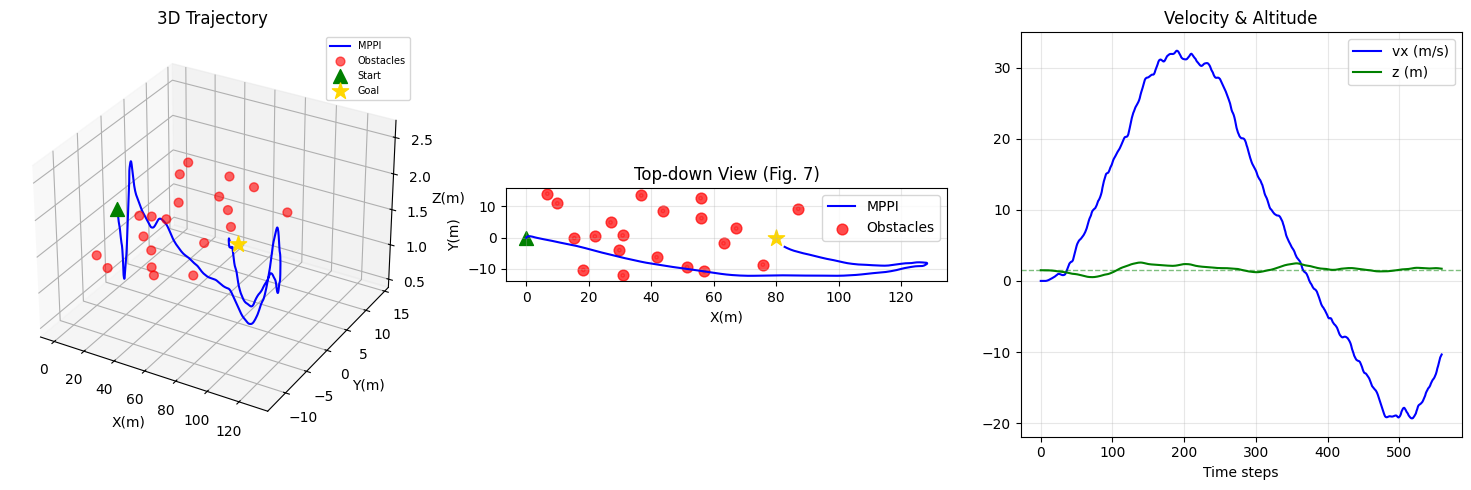


=== Results ===
Final position  : (82.7, -2.9, 1.72)
Avg forward vel : 7.37 m/s
Collision steps : 1
Goal reached    : Yes!


In [ ]:
# ====== Quadrotor 통합 셀 ======
import os
os.environ['MUJOCO_GL'] = 'egl'

import torch
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── 파라미터 ─────────────────────────────────────────────────
m    = 0.25
g    = 9.81
L    = 0.1
kF   = 6.11e-8
kM   = 1.5e-9
Ixx  = 2.5e-4
Iyy  = 2.5e-4
Izz  = 1.2e-3
km   = 20.0
w_hover = float(np.sqrt(m * g / (4 * kF)))
print(f"Hover RPM: {w_hover:.1f}")

# ── MPPI 클래스 ──────────────────────────────────────────────
class MPPI:
    def __init__(self, dynamics_fn, cost_fn, n_state, n_ctrl,
                 horizon, n_rollouts, lambda_, sigma,
                 u_min=None, u_max=None, dt=0.02):
        self.dynamics = dynamics_fn
        self.cost     = cost_fn
        self.T        = horizon
        self.K        = n_rollouts
        self.lambda_  = lambda_

        self.sigma = sigma.to(device) if isinstance(sigma, torch.Tensor) \
                     else torch.ones(n_ctrl, device=device) * sigma

        if u_min is not None:
            self.u_min = u_min.to(device) if isinstance(u_min, torch.Tensor) \
                         else torch.full((n_ctrl,), u_min, device=device)
            self.u_max = u_max.to(device) if isinstance(u_max, torch.Tensor) \
                         else torch.full((n_ctrl,), u_max, device=device)
        else:
            self.u_min = self.u_max = None

        self.U = torch.zeros(horizon, n_ctrl, device=device)

    @torch.no_grad()
    def step(self, state):
        x0      = torch.tensor(state, dtype=torch.float32, device=device)
        delta_u = torch.randn(self.K, self.T, self.U.shape[1], device=device) \
                  * self.sigma.unsqueeze(0).unsqueeze(0)
        U_pert  = self.U.unsqueeze(0) + delta_u
        if self.u_min is not None:
            U_pert = torch.max(torch.min(U_pert, self.u_max.view(1,1,-1)),
                               self.u_min.view(1,1,-1))
        traj    = self.dynamics(x0.unsqueeze(0).expand(self.K,-1), U_pert)
        costs   = self.cost(traj, U_pert)
        beta    = costs.min()
        w       = torch.exp(-(costs-beta)/self.lambda_)
        w       = w / w.sum()
        self.U  = self.U + (w.view(self.K,1,1) * delta_u).sum(0)
        if self.u_min is not None:
            self.U = torch.max(torch.min(self.U, self.u_max), self.u_min)
        u_exec  = self.U[0].cpu().numpy()
        self.U  = torch.roll(self.U, -1, dims=0)
        self.U[-1] = w_hover
        return u_exec

    def reset(self):
        self.U = torch.zeros(self.T, self.U.shape[1], device=device)
        self.U[:] = w_hover

# ── Dynamics ─────────────────────────────────────────────────
def quadrotor_dynamics_batch(states, controls, dt=0.02):
    K, T  = states.shape[0], controls.shape[1]
    traj  = torch.zeros(K, T, 16, device=states.device, dtype=states.dtype)
    x_cur = states.clone()

    for t in range(T):
        w_des = controls[:, t, :]

        vx, vy, vz     = x_cur[:,3], x_cur[:,4], x_cur[:,5]
        phi, theta, psi = x_cur[:,6], x_cur[:,7], x_cur[:,8]
        p, q, r         = x_cur[:,9], x_cur[:,10], x_cur[:,11]
        w1,w2,w3,w4     = x_cur[:,12],x_cur[:,13],x_cur[:,14],x_cur[:,15]

        F1=kF*w1**2; F2=kF*w2**2; F3=kF*w3**2; F4=kF*w4**2
        M1=kM*w1**2; M2=kM*w2**2; M3=kM*w3**2; M4=kM*w4**2
        Ft = F1+F2+F3+F4

        cphi=torch.cos(phi); sphi=torch.sin(phi)
        cth=torch.cos(theta); sth=torch.sin(theta)
        cpsi=torch.cos(psi); spsi=torch.sin(psi)

        ax = (cpsi*sth*cphi + spsi*sphi) * Ft/m
        ay = (spsi*sth*cphi - cpsi*sphi) * Ft/m
        az = (cth*cphi)                  * Ft/m - g

        cth_s = cth.abs().clamp(min=1e-4)
        phi_dot   = p + (q*sphi + r*cphi)*sth/cth_s
        theta_dot = q*cphi - r*sphi
        psi_dot   = (q*sphi + r*cphi)/cth_s

        tau_phi   = L*(F2-F4)
        tau_theta = L*(F3-F1)
        tau_psi   = M1-M2+M3-M4

        p_dot = (tau_phi   - (Iyy-Izz)*q*r) / Ixx
        q_dot = (tau_theta - (Izz-Ixx)*p*r) / Iyy
        r_dot = (tau_psi   - (Ixx-Iyy)*p*q) / Izz

        x_next = torch.stack([
            x_cur[:,0] + vx*dt,
            x_cur[:,1] + vy*dt,
            x_cur[:,2] + vz*dt,
            vx + ax*dt,
            vy + ay*dt,
            vz + az*dt,
            phi   + phi_dot*dt,
            theta + theta_dot*dt,
            psi   + psi_dot*dt,
            p + p_dot*dt,
            q + q_dot*dt,
            r + r_dot*dt,
            (w1 + km*(w_des[:,0]-w1)*dt).clamp(min=0),
            (w2 + km*(w_des[:,1]-w2)*dt).clamp(min=0),
            (w3 + km*(w_des[:,2]-w3)*dt).clamp(min=0),
            (w4 + km*(w_des[:,3]-w4)*dt).clamp(min=0),
        ], dim=1)

        traj[:,t,:] = x_next
        x_cur = x_next

    return traj

# ── 장애물 ───────────────────────────────────────────────────
def make_obstacle_field(n_obstacles=20, seed=42, min_dist=4.0):
    rng = np.random.RandomState(seed)
    obstacles = []
    while len(obstacles) < n_obstacles:
        ox = rng.uniform(5, 90)
        oy = rng.uniform(-15, 15)
        if all(np.sqrt((ox-o[0])**2+(oy-o[1])**2) > min_dist
               for o in obstacles):
            obstacles.append([ox, oy])
    return np.array(obstacles)

obstacles   = make_obstacle_field(n_obstacles=20, min_dist=4.0)
obs_tensor  = torch.tensor(obstacles, dtype=torch.float32, device=device)
print(f"Generated {len(obstacles)} obstacles")

# ── Cost ─────────────────────────────────────────────────────
def quadrotor_cost(trajectories, controls,
                   obs=None, goal=np.array([80.0, 0.0, 1.5])):
    px=trajectories[:,:,0]; py=trajectories[:,:,1]; pz=trajectories[:,:,2]
    vx=trajectories[:,:,3]; vy=trajectories[:,:,4]; vz=trajectories[:,:,5]
    psi=trajectories[:,:,8]

    cost = (2.5*(px-goal[0])**2 + 2.5*(py-goal[1])**2
            + 150.0*(pz-goal[2])**2 + 50.0*psi**2
            + vx**2+vy**2+vz**2)

    if obs is not None:
        for o in obs:
            d = torch.sqrt((px-o[0])**2 + (py-o[1])**2 + 1e-6)
            cost += 350.0*torch.exp(-d/12.0)
            cost += 1000.0*(d < 0.5).float()

    return cost.sum(dim=1)

# ── MPPI 생성 ────────────────────────────────────────────────
def make_quadrotor_mppi(n_rollouts=1000):
    # hover rpm 기준으로 초기 제어 시퀀스를 hover로 설정
    mppi = MPPI(
        dynamics_fn=lambda s,u: quadrotor_dynamics_batch(s,u,dt=0.02),
        cost_fn=lambda traj,u: quadrotor_cost(traj,u,obs=obs_tensor),
        n_state=16, n_ctrl=4,
        horizon=60,
        n_rollouts=n_rollouts,
        lambda_=0.5,
        sigma=torch.tensor([w_hover*0.15]*4),  # 0.08 → 0.15 (탐색 확대)
        u_min=torch.tensor([w_hover*0.3]*4),   # 최소 rpm 보장 (추락 방지)
        u_max=torch.tensor([w_hover*2.5]*4),
        dt=0.02,
    )
    # 초기 제어 시퀀스를 hover rpm으로 설정 (0이 아닌 hover로 warm start)
    mppi.U = torch.full((60, 4), w_hover, device=device)
    return mppi

# ── 실행 ─────────────────────────────────────────────────────
def run_quadrotor(n_rollouts=1000, sim_steps=1000):
    state = np.array([
        0.,0.,1.5, 0.,0.,0., 0.,0.,0., 0.,0.,0.,
        w_hover,w_hover,w_hover,w_hover
    ], dtype=np.float32)

    mppi = make_quadrotor_mppi(n_rollouts)
    log  = {k:[] for k in ['x','y','z','vx','cost']}

    print(f"Running Quadrotor MPPI: K={n_rollouts}, {sim_steps} steps")
    t0 = time.time()

    for step in range(sim_steps):
        u     = mppi.step(state)
        s_t   = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        u_t   = torch.tensor(u, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
        state = quadrotor_dynamics_batch(s_t, u_t, dt=0.02)[0,0].cpu().numpy()

        x,y,z,vx = state[0],state[1],state[2],state[3]
        dists = np.sqrt((obstacles[:,0]-x)**2+(obstacles[:,1]-y)**2)
        cost  = 2.5*(x-80)**2+2.5*y**2+150*(z-1.5)**2+350*np.exp(-dists.min()/12)

        for k,v in zip(['x','y','z','vx','cost'],[x,y,z,vx,cost]):
            log[k].append(v)

        if step % 200 == 0:
            print(f"  step {step:4d} | pos=({x:.1f},{y:.1f},{z:.2f}) "
                  f"vx={vx:.2f} | min_dist={dists.min():.2f}")

        if x > 78.0 and abs(y) < 3.0:
            print(f"  Goal reached at step {step}!")
            break

    print(f"Done {time.time()-t0:.1f}s | final=({state[0]:.1f},{state[1]:.1f},{state[2]:.2f})")
    return {k: np.array(v) for k,v in log.items()}


log = run_quadrotor(n_rollouts=1000, sim_steps=1000)

# ── 플롯 ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(15,5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(log['x'],log['y'],log['z'],'b-',lw=1.5,label='MPPI')
ax1.scatter(obstacles[:,0],obstacles[:,1],
            np.ones(len(obstacles))*1.5,c='red',s=40,alpha=0.6,label='Obstacles')
ax1.scatter([0],[0],[1.5],c='green',s=100,marker='^',label='Start')
ax1.scatter([80],[0],[1.5],c='gold',s=150,marker='*',label='Goal')
ax1.set_xlabel('X(m)');ax1.set_ylabel('Y(m)');ax1.set_zlabel('Z(m)')
ax1.set_title('3D Trajectory');ax1.legend(fontsize=7)

ax2 = fig.add_subplot(132)
ax2.plot(log['x'],log['y'],'b-',lw=1.5,label='MPPI')
ax2.scatter(obstacles[:,0],obstacles[:,1],c='red',s=60,alpha=0.7,label='Obstacles')
for ox,oy in obstacles:
    ax2.add_patch(plt.Circle((ox,oy),0.5,color='red',fill=False,alpha=0.4))
ax2.scatter([0],[0],c='green',s=100,marker='^')
ax2.scatter([80],[0],c='gold',s=150,marker='*')
ax2.set_xlabel('X(m)');ax2.set_ylabel('Y(m)')
ax2.set_title('Top-down View (Fig. 7)')
ax2.set_aspect('equal');ax2.legend();ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(133)
ax3.plot(log['vx'],'b-',lw=1.5,label='vx (m/s)')
ax3.plot(log['z'], 'g-',lw=1.5,label='z (m)')
ax3.axhline(1.5,color='g',ls='--',lw=1,alpha=0.5)
ax3.set_xlabel('Time steps');ax3.set_title('Velocity & Altitude')
ax3.legend();ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('quadrotor_result.png',dpi=150)
plt.show()

# 충돌 체크
collisions = sum(
    np.sqrt((obstacles[:,0]-log['x'][i])**2+(obstacles[:,1]-log['y'][i])**2).min() < 0.5
    for i in range(len(log['x']))
)
print(f"\n=== Results ===")
print(f"Final position  : ({log['x'][-1]:.1f}, {log['y'][-1]:.1f}, {log['z'][-1]:.2f})")
print(f"Avg forward vel : {np.mean(log['vx']):.2f} m/s")
print(f"Collision steps : {collisions}")
print(f"Goal reached    : {'Yes!' if log['x'][-1]>78 else 'No'}")